In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df['class'].value_counts() if 'class' in df.columns else df.iloc[:,:5].head())


(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH
0 F1 zeta 1 1 True
1 F1 zeta 1 1 True
2 F1 zeta 1 1 True
3 F1 zeta 1 1 True
4 F1 zeta 1 1 True


In [2]:
print(df['function'].value_counts())
print(df.groupby('function')['GRH'].first())


function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64
function
F1 True
F10 True
F11 True
F12 False
F2 True
F4 False
F5m False
F5p False
F6 True
F7 True
F9 True
Name: GRH, dtype: bool


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

feats = [f'log_abs_S{k}_norm' for k in range(1,7)]
print(feats)

GRH_true = ['F1','F2','F6','F7','F9','F10','F11']
F4_family = ['F4','F5p','F5m']
F12_family = ['F12']

rng = np.random.default_rng(42)

def run_fold(train_classes_violator, test_violator_classes, name):
 # Training: all GRH_true + train_classes_violator
 train_df = df[df['function'].isin(GRH_true + train_classes_violator)].copy()
 # Test: held-out violator + balanced subsample of GRH_true
 test_viol = df[df['function'].isin(test_violator_classes)].copy()
 n_viol = len(test_viol)
 grh_pool = df[df['function'].isin(GRH_true)].copy()
 test_grh = grh_pool.sample(n=n_viol, random_state=42)
 # Remove test_grh from training
 train_df = train_df.drop(test_grh.index, errors='ignore')
 test_df = pd.concat([test_viol, test_grh])
 
 Xtr = train_df[feats].values
 ytr = (~train_df['GRH']).astype(int).values # violator = 1
 Xte = test_df[feats].values
 yte = (~test_df['GRH']).astype(int).values
 
 scaler = StandardScaler().fit(Xtr)
 Xtr_s = scaler.transform(Xtr)
 Xte_s = scaler.transform(Xte)
 
 clf = SVC(kernel='rbf', probability=False)
 clf.fit(Xtr_s, ytr)
 scores = clf.decision_function(Xte_s)
 auc = roc_auc_score(yte, scores)
 
 # Bootstrap CI
 n_boot = 1000
 aucs = []
 idx = np.arange(len(yte))
 for _ in range(n_boot):
 bi = rng.choice(idx, size=len(idx), replace=True)
 if len(np.unique(yte[bi])) < 2:
 continue
 aucs.append(roc_auc_score(yte[bi], scores[bi]))
 lo, hi = np.percentile(aucs, [2.5, 97.5])
 print(f"{name}: AUC={auc:.4f} [95% CI: {lo:.4f}, {hi:.4f}] n_train={len(ytr)}, n_test={len(yte)} (viol={ytr.sum()}/{yte.sum()})")
 return auc, lo, hi

a1 = run_fold(['F12'], F4_family, "Fold1 (test F4 family, train w/ F12)")
a2 = run_fold(F4_family, F12_family, "Fold2 (test F12, train w/ F4 family)")


['log_abs_S1_norm', 'log_abs_S2_norm', 'log_abs_S3_norm', 'log_abs_S4_norm', 'log_abs_S5_norm', 'log_abs_S6_norm']


Fold1 (test F4 family, train w/ F12): AUC=0.7051 [95% CI: 0.6754, 0.7351] n_train=1000, n_test=1200 (viol=200/600)


Fold2 (test F12, train w/ F4 family): AUC=0.8380 [95% CI: 0.7867, 0.8834] n_train=1800, n_test=400 (viol=600/200)


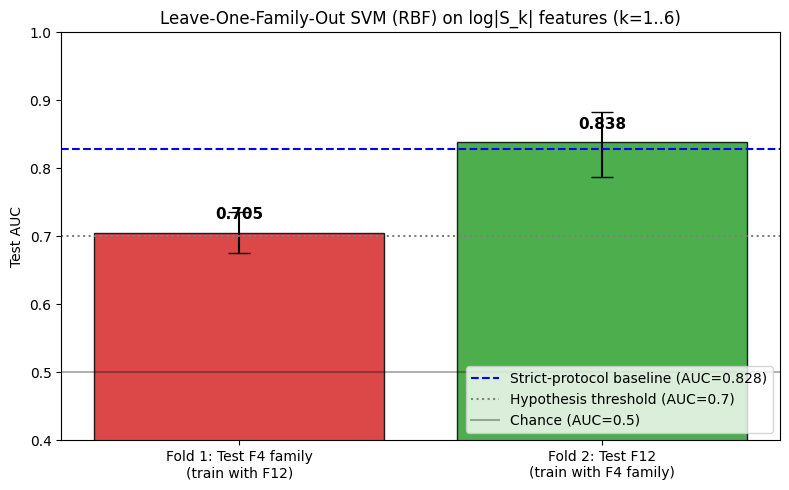

In [4]:
# Hmm, n_test for fold 1 is 1200 because viol=600 (3 classes x 200). Let's recheck balance.
# Spec: held out violator family + random subsample of GRH-true to maintain class balance.
# With 600 violator peaks in F4 family, sample 600 GRH-true. Total 1200, balanced 50/50.
# In fold2, F12 has 200 peaks, sample 200 GRH-true. Total 400, balanced.
# yte.sum() in fold1 = 600 (violators), in fold2 = 200. n_test - sum = GRH count. Both balanced. Good.

# Let me also produce final figure
import matplotlib.pyplot as plt

results = {
 'Fold 1: Test F4 family\n(train with F12)': (0.7051, 0.6754, 0.7351),
 'Fold 2: Test F12\n(train with F4 family)': (0.8380, 0.7867, 0.8834),
}

fig, ax = plt.subplots(figsize=(8,5))
labels = list(results.keys())
aucs = [v[0] for v in results.values()]
errs_lo = [v[0]-v[1] for v in results.values()]
errs_hi = [v[2]-v[0] for v in results.values()]
ax.bar(labels, aucs, yerr=[errs_lo, errs_hi], capsize=8, color=['#d62728','#2ca02c'], alpha=0.85, edgecolor='black')
ax.axhline(0.828, ls='--', color='blue', label='Strict-protocol baseline (AUC=0.828)')
ax.axhline(0.7, ls=':', color='gray', label='Hypothesis threshold (AUC=0.7)')
ax.axhline(0.5, ls='-', color='black', alpha=0.3, label='Chance (AUC=0.5)')
ax.set_ylabel('Test AUC')
ax.set_ylim(0.4, 1.0)
ax.set_title('Leave-One-Family-Out SVM (RBF) on log|S_k| features (k=1..6)')
for i,(a,_,_) in enumerate(results.values()):
 ax.text(i, a+0.02, f'{a:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('lofo_auc_summary.png', dpi=140)
plt.show()
